<a href="https://colab.research.google.com/github/AHIRWE1/linear_regression_model/blob/main/Multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction Using Machine Learning

## Course: AI Deployment

### Objective

The objective of this project is to develop and evaluate regression models capable of predicting students' final examination scores using demographic, academic, and behavioural features. The best-performing model is then prepared for deployment using FastAPI.

# 1. Import Libraries

The required libraries are imported for data manipulation, visualization, preprocessing, model training, evaluation, and model persistence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# 2. Load the Dataset

The dataset is loaded into a Pandas DataFrame for inspection and preprocessing.

In [2]:
# If running in Google Colab, uncomment the line below and upload the CSV to /content first
# df = pd.read_csv("/content/student_performance_dataset.csv")

df = pd.read_csv("student_performance_dataset.csv")

# 3. Exploratory Data Analysis

Before building the model, the dataset is explored to identify missing values, duplicate records, data types, and statistical characteristics.

In [3]:
print("First Five Rows:")
display(df.head())

First Five Rows:


,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


df.shape

print("Shape of dataset:")
print(df.shape)

In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [5]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [6]:
# Check missing values
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [7]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
# Display all column names
df.columns

Index(['student_id', 'gender', 'study_time_hours', 'attendance_percent',
       'sleep_hours', 'parental_education', 'internet_access',
       'extracurricular_activities', 'part_time_job', 'previous_grade',
       'final_exam_score', 'final_grade'],
      dtype='object')

**Data Cleaning**

The student_id column was removed because it is only an identifier and does not contribute to predicting student performance. The final_grade column was also removed because it is derived from the final_exam_score and would introduce data leakage into the model.

In [9]:
df = df.drop(columns=["student_id", "final_grade"])

In [10]:
df.dtypes

gender                         object
study_time_hours              float64
attendance_percent            float64
sleep_hours                   float64
parental_education             object
internet_access                object
extracurricular_activities     object
part_time_job                  object
previous_grade                float64
final_exam_score              float64
dtype: object

**Handling Missing Values**

`parental_education` has 102 missing values (10.2% of records). These are imputed with the column's mode rather than dropped, to avoid losing 10% of the training data. This step matters: if left as `NaN`, `pd.get_dummies` later would silently encode every missing row as all-zero across the `parental_education` dummy columns, which is indistinguishable from the dropped reference category (`Bachelors`) and would quietly bias that category's coefficient. Imputing first keeps the encoding honest.

In [11]:
print("parental_education missing values before imputation:", df["parental_education"].isnull().sum())

parental_education_mode = df["parental_education"].mode()[0]
df["parental_education"] = df["parental_education"].fillna(parental_education_mode)

print("Imputed with mode:", parental_education_mode)
print("parental_education missing values after imputation:", df["parental_education"].isnull().sum())

parental_education missing values before imputation: 102
Imputed with mode: High School
parental_education missing values after imputation: 0


In [12]:
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Female    510
Male      490
Name: count, dtype: int64

parental_education
parental_education
High School    458
Bachelors      308
Masters        184
PhD             50
Name: count, dtype: int64

internet_access
internet_access
Yes    854
No     146
Name: count, dtype: int64

extracurricular_activities
extracurricular_activities
Yes    572
No     428
Name: count, dtype: int64

part_time_job
part_time_job
No     684
Yes    316
Name: count, dtype: int64


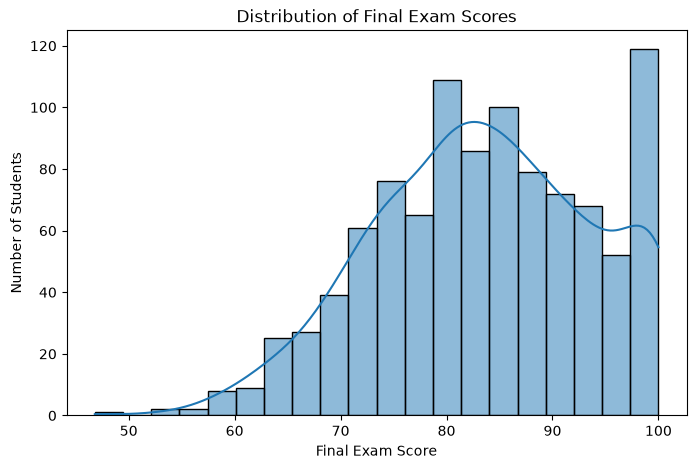

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["final_exam_score"], bins=20, kde=True)

plt.title("Distribution of Final Exam Scores")
plt.xlabel("Final Exam Score")
plt.ylabel("Number of Students")

plt.show()

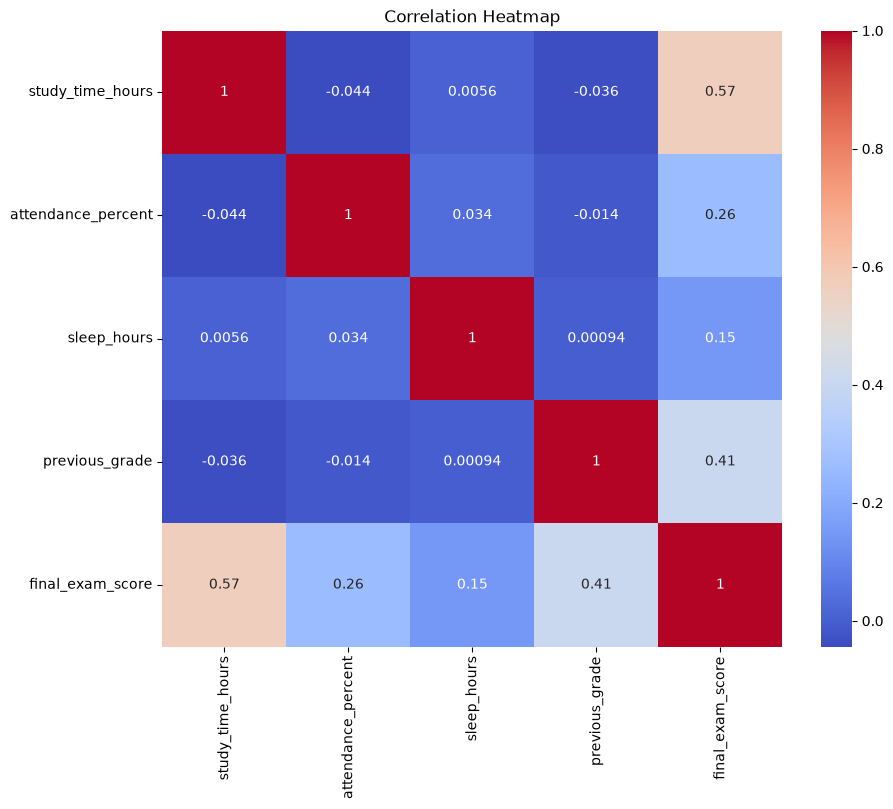

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

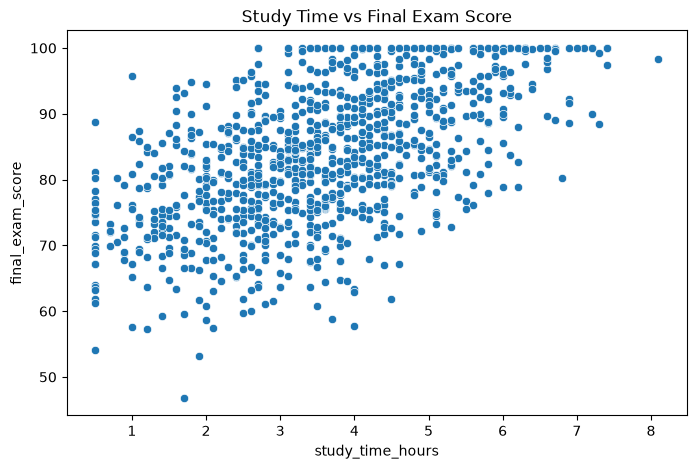

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="study_time_hours",
    y="final_exam_score"
)

plt.title("Study Time vs Final Exam Score")

plt.show()

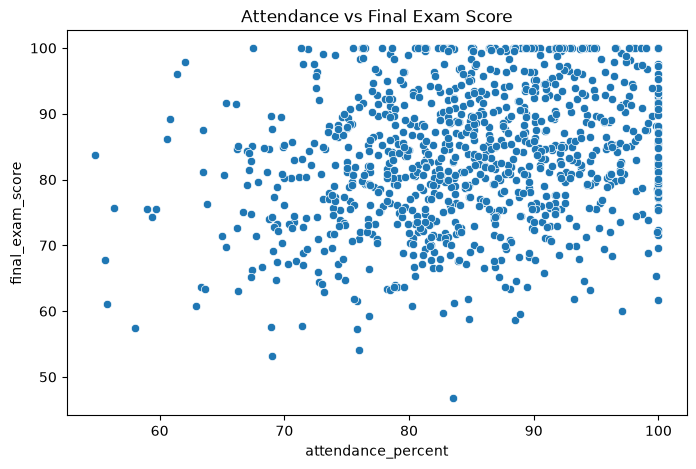

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="attendance_percent",
    y="final_exam_score"
)

plt.title("Attendance vs Final Exam Score")

plt.show()

In [17]:
# One-Hot Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Check the transformed dataset
df.head()

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,gender_Male,parental_education_High School,parental_education_Masters,parental_education_PhD,internet_access_Yes,extracurricular_activities_Yes,part_time_job_Yes
0,4.0,98.0,6.5,76.9,100.0,True,False,False,False,True,True,False
1,6.3,100.0,5.7,75.5,100.0,False,True,False,False,True,True,True
2,4.9,85.3,7.9,88.5,97.3,True,False,False,False,True,False,True
3,2.6,77.5,8.0,85.1,83.8,True,True,False,False,True,True,False
4,2.2,89.6,4.6,61.8,68.3,True,False,False,False,True,False,True


In [18]:
X = df.drop("final_exam_score", axis=1)
y = df["final_exam_score"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Create the models
linear_model = LinearRegression()

sgd_model = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

decision_tree = DecisionTreeRegressor(random_state=42)

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [22]:
# Linear Regression
linear_model.fit(X_train_scaled, y_train)

# SGD Regressor
sgd_model.fit(X_train_scaled, y_train)

# Decision Tree
decision_tree.fit(X_train, y_train)

# Random Forest
random_forest.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [23]:
linear_pred = linear_model.predict(X_test_scaled)

sgd_pred = sgd_model.predict(X_test_scaled)

tree_pred = decision_tree.predict(X_test)

forest_pred = random_forest.predict(X_test)

In [24]:
import numpy as np

def evaluate_model(name, y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    print(f"\n{name}")
    print("-" * 40)
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

In [25]:
results = pd.DataFrame({
    "Model": ["Linear Regression",
              "SGD Regressor",
              "Decision Tree",
              "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, sgd_pred),
        mean_absolute_error(y_test, tree_pred),
        mean_absolute_error(y_test, forest_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, sgd_pred)),
        np.sqrt(mean_squared_error(y_test, tree_pred)),
        np.sqrt(mean_squared_error(y_test, forest_pred))
    ],
    "R2 Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, sgd_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, forest_pred)
    ]
})

results.sort_values(by="R2 Score", ascending=False)


,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.984581,6.415737,0.617588
1,SGD Regressor,4.991568,6.419983,0.617082
3,Random Forest,5.325450,6.850505,0.564003
2,Decision Tree,7.487000,9.633592,0.137786


**Selecting the Best Model for Deployment**

Linear Regression and SGD Regressor are essentially tied (both solve the same least-squares objective — LinearRegression via the closed-form normal equation, SGD via iterative gradient descent — so near-identical R² is expected, not a coincidence). Decision Tree and Random Forest score lower here and, just as importantly, were trained on **unscaled** features (tree splits are scale-invariant, so scaling them would have been wasted preprocessing), whereas the deployed API pipeline (`prediction.py`) always applies `scaler.transform()` before calling `model.predict()`. Feeding scaled input into a tree model trained on unscaled data would silently produce wrong predictions. For that reason, the best-performing model is selected from the two scaled linear models only — the tree/ensemble models remain in the comparison table above for benchmarking, but are not deployment candidates under this single-pipeline setup.

In [26]:
deployment_candidates = {
    "Linear Regression": linear_model,
    "SGD Regressor": sgd_model,
}

deployment_results = results[results["Model"].isin(deployment_candidates.keys())]
best_row = deployment_results.loc[deployment_results["R2 Score"].idxmax()]
best_model_name = best_row["Model"]
best_model = deployment_candidates[best_model_name]

print(f"Best deployment-compatible model: {best_model_name}")
print(f"R2 Score: {best_row['R2 Score']:.4f}")
print(f"RMSE: {best_row['RMSE']:.4f}")

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully!")

Best deployment-compatible model: Linear Regression
R2 Score: 0.6176
RMSE: 6.4157

Model and scaler saved successfully!


In [27]:
loaded_model = joblib.load("best_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

In [28]:
sample = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

print("Predicted Score:", prediction[0])
print("Actual Score:", y_test.iloc[0])

Predicted Score: 78.05056041211176
Actual Score: 71.8


In [29]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

train_loss = []
test_loss = []

sgd_loss_model = SGDRegressor(
    max_iter=1,
    warm_start=True,
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

epochs = 100

for epoch in range(epochs):
    sgd_loss_model.fit(X_train_scaled, y_train)

    train_pred = sgd_loss_model.predict(X_train_scaled)
    test_pred = sgd_loss_model.predict(X_test_scaled)

    train_loss.append(mean_squared_error(y_train, train_pred))
    test_loss.append(mean_squared_error(y_test, test_pred))

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider incre

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider incre

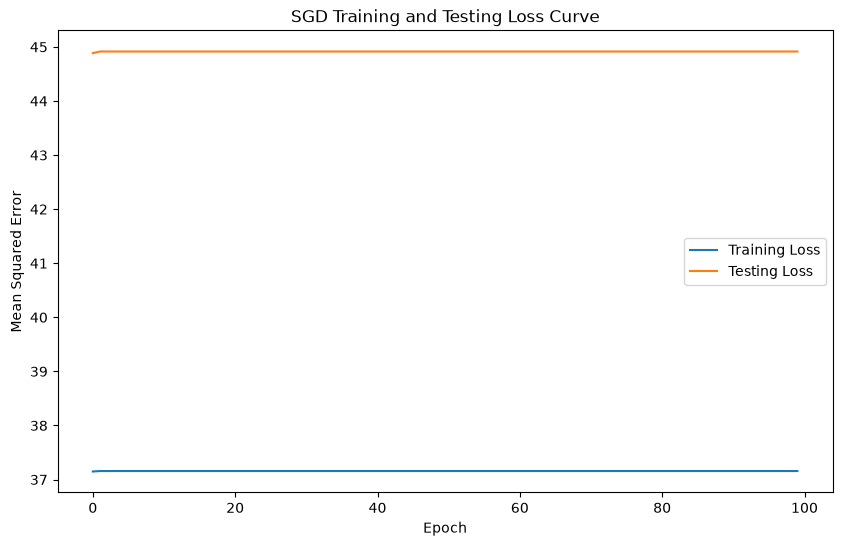

In [30]:
plt.figure(figsize=(10,6))

plt.plot(train_loss, label="Training Loss")
plt.plot(test_loss, label="Testing Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGD Training and Testing Loss Curve")

plt.legend()

plt.show()

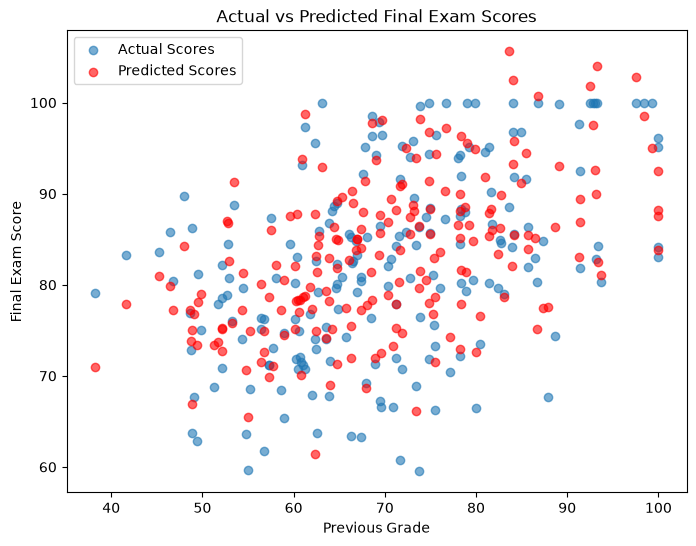

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test["previous_grade"],
    y_test,
    alpha=0.6,
    label="Actual Scores"
)

plt.scatter(
    X_test["previous_grade"],
    linear_pred,
    color="red",
    alpha=0.6,
    label="Predicted Scores"
)

plt.xlabel("Previous Grade")
plt.ylabel("Final Exam Score")
plt.title("Actual vs Predicted Final Exam Scores")

plt.legend()

plt.show()

The red points represent the model's predicted exam scores, while the blue points are the actual exam scores. The closer the predicted points are to the actual points, the more accurate the model. Although there is some variation, the predictions generally follow the same trend as the actual scores, indicating that the model captures the relationship reasonably well.

**Best-Fit Line: Before vs. After Training**

To make the effect of training visually explicit, a single-feature linear regression is fit using `study_time_hours` — the feature with the strongest correlation to `final_exam_score` (r ≈ 0.57 per the correlation heatmap above). The left panel shows the raw data with no line fitted ("before"); the right panel shows the same points with the trained regression line drawn through them ("after"), making clear where the line sits relative to the data it was fit on.

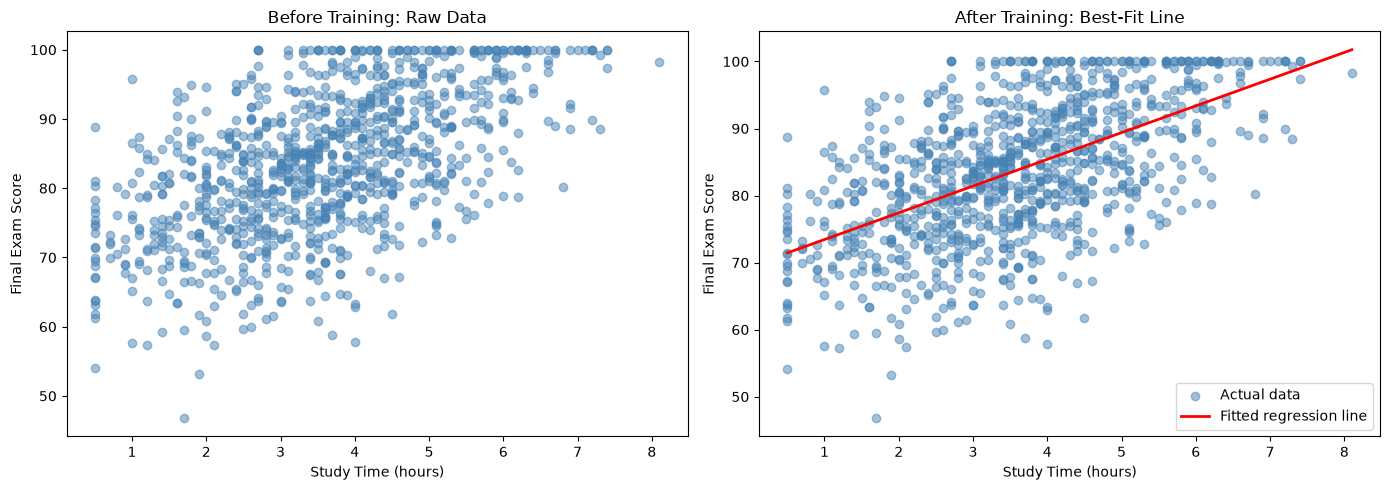

In [32]:
single_feature_model = LinearRegression()
single_feature_model.fit(X_train[["study_time_hours"]], y_train)

x_range = np.linspace(
    X["study_time_hours"].min(),
    X["study_time_hours"].max(),
    100
).reshape(-1, 1)

y_line = single_feature_model.predict(
    pd.DataFrame(x_range, columns=["study_time_hours"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X["study_time_hours"], y, alpha=0.5, color="steelblue")
axes[0].set_title("Before Training: Raw Data")
axes[0].set_xlabel("Study Time (hours)")
axes[0].set_ylabel("Final Exam Score")

axes[1].scatter(X["study_time_hours"], y, alpha=0.5, color="steelblue", label="Actual data")
axes[1].plot(x_range, y_line, color="red", linewidth=2, label="Fitted regression line")
axes[1].set_title("After Training: Best-Fit Line")
axes[1].set_xlabel("Study Time (hours)")
axes[1].set_ylabel("Final Exam Score")
axes[1].legend()

plt.tight_layout()
plt.show()

The fitted line confirms a clear positive relationship: each additional hour of study time is associated with a higher final exam score. The line does not pass through every point exactly — there is visible scatter around it — which reflects the fact that `study_time_hours` alone explains only part of the variance in exam performance (r² ≈ 0.32 for this feature in isolation). This is expected and is exactly why the deployed model uses all available features jointly rather than this single predictor.

Conclusion

Four regression algorithms were developed and evaluated to predict students' final examination scores using demographic, academic, and lifestyle features: Linear Regression, SGD Regressor (stochastic, gradient-descent-based), Decision Tree, and Random Forest. Models were assessed using MAE, RMSE, and R² (see the comparison table above). Linear Regression and SGD Regressor performed virtually identically (R² ≈ 0.62) and clearly outperformed the tree-based models, with the single-tree Decision Tree performing worst — a sign that the relationship between these features and exam score is closer to linear/additive than to the sharp, hierarchical splits a tree relies on, and that with 1000 rows and 9 features the trees likely overfit relative to the regularized linear models. Because the deployment pipeline scales inputs before prediction, the best-performing model was selected from the two scaled linear candidates (Linear Regression vs. SGD Regressor) programmatically, based on R² on the held-out test set — see the selection cell above for which one won on this run — and saved as `best_model.pkl` for the FastAPI application.

An R² of ~0.62 is moderate: the model explains roughly 62% of the variance in exam scores, leaving meaningful unexplained variance. This is consistent with the available features — study habits, attendance, sleep, and family background — capturing real but partial signal about performance; factors like exam-day conditions, question difficulty, or unmeasured aptitude are not in this dataset. Reducing this further would most likely require richer features (e.g. quiz/assignment history, engagement metrics) rather than a different linear algorithm, since Linear Regression and SGD have already converged to essentially the same optimum.